# ✈ Download the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path ='/content/drive/MyDrive/Project ML/Dataset/Cyber Bully/Formspring.csv'

In [ ]:
!pip install emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 5.2 MB/s eta 0:00:00


# 📚 Read data

## ⚓ Config

In [ ]:
config = {
    "data_path":{
        'data' : path
    }
}

## ⚓ Read

In [ ]:
import pandas as pd

file_path = config["data_path"]["data"]
df = pd.read_csv(file_path)
df.head()

,text,answer
0,Q: what&#039;s your favorite song? :D<br>A: I ...,No
1,Q: <3<br>A: </3 ? haha jk! <33,No
2,Q: &quot;hey angel you duh sexy&quot;<br>A: R...,No
3,Q: (:<br>A: ;(,No
4,Q: ******************MEOWWW*******************...,No


# ⚓ EDA

In [ ]:
print(df.shape)
print("This dataset has 13147 row and 2 columns")

(13147, 2)
This dataset has 13147 row and 2 columns


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13147 entries, 0 to 13146
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    13147 non-null  object
 1   answer  13147 non-null  object
dtypes: object(2)
memory usage: 205.6+ KB


In [ ]:
print('generate descriptive statistics of the dataset')
print('-' * 70)
print(df.describe())

generate descriptive statistics of the dataset
----------------------------------------------------------------------
                                                     text answer
count                                               13147  13147
unique                                              13144      2
top     Q: Wait. Are you Cheyenne? I sent a request to...     No
freq                                                    3  12295


### ♒ Check for missing values

In [ ]:
print('Missing value:')
print(df.isnull().sum())

Missing value:
text      0
answer    0
dtype: int64


### ♒ Check for values count

In [ ]:
print('Check for values count of element "answer":')
print('-' * 70)
print(df["answer"].value_counts())
print('-' * 70)
print("The data are Imbalanced")

Check for values count of element "answer":
----------------------------------------------------------------------
answer
No     12295
Yes      852
Name: count, dtype: int64
----------------------------------------------------------------------
The data are Imbalanced


# ⚓ Preprocessing

## ♒ Pre-Clean

In [ ]:
import html
import re

def pre_clean_html(text):
    text = str(text)
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)

    return text

## ♒ Preprocessing

In [ ]:
import string
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).translate(str.maketrans('', '', string.punctuation))
    tokens = [word for word in text.split() if word.lower() not in stop_words]
    return ' '.join(lemmatizer.lemmatize(word) for word in tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## ♒ Clean Social Media Text

In [ ]:
import re
import emoji

def clean_social_media_noise(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = text.replace('#', '')
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

sample_text = "You are such a loser!!! 😡🤬 @johndoe check this out http://fake.link.com #hate #cyberbullying"
cleaned_text = clean_social_media_noise(sample_text)

print("Original:", sample_text)
print("Cleaned:", cleaned_text)

Original: You are such a loser!!! 😡🤬 @johndoe check this out http://fake.link.com #hate #cyberbullying
Cleaned: You are such a loser!!! check this out hate cyberbullying


## ♒ Text feature extraction

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

df["text"] = df["text"].apply(pre_clean_html)
df["text"] = df["text"].apply(clean_social_media_noise)
df["text"] = df["text"].apply(preprocess)

tfidf_vector = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95)
df_features = tfidf_vector.fit_transform(df["text"])
print(df_features.shape)

(13147, 10000)


# ⚓ Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["answer"] = le.fit_transform(df["answer"])
df.head(6)

,text,answer
0,Q whats favorite song like many song favorite,0
1,Q 3 haha jk 33,0
2,Q hey angel duh sexy Really Thanks haha,0
3,Q,0
4,Q MEOWWW RAWR,0
5,Q makeup tip suck makeup lol Sure Like tell wh...,0


# ⚓ Model Evaluation

## ♒ Train/test/split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_features, df["answer"], test_size=0.2, random_state=42)

## ♒ SVC model

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
svc = SVC(kernel="linear", gamma=1.0, class_weight="balanced")
svc.fit(X_train, y_train)
svc_prediction = svc.predict(X_test)
svc_accuracy = accuracy_score(y_test, svc_prediction)
svc_precision = precision_score(y_test, svc_prediction)
svc_recall = recall_score(y_test, svc_prediction)
svc_f1 = f1_score(y_test, svc_prediction)
print("Model type: SVC")
print("-" * 70)
print(f"Accuracy: {svc_accuracy}")
print(f"Precision: {svc_precision}")
print(f"Recall: {svc_recall}")
print(f"F1: {svc_f1}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, svc_prediction))
print("Classification Report:")
print(classification_report(y_test, svc_prediction))

Model type: SVC
----------------------------------------------------------------------
Accuracy: 0.9224334600760457
Precision: 0.4266666666666667
Recall: 0.5614035087719298
F1: 0.48484848484848486
Confusion Matrix:
[[2330  129]
 [  75   96]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      2459
           1       0.43      0.56      0.48       171

    accuracy                           0.92      2630
   macro avg       0.70      0.75      0.72      2630
weighted avg       0.93      0.92      0.93      2630



## ♒MNB model (Multinomial Naive Bayes model)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB(alpha=0.2)
mnb.fit(X_train_balanced, y_train_balanced)
mnb_prediction = mnb.predict(X_test)
mnb_accuracy = accuracy_score(y_test, mnb_prediction)
mnb_precision = precision_score(y_test, mnb_prediction)
mnb_recall = recall_score(y_test, mnb_prediction)
mnb_f1 = f1_score(y_test, mnb_prediction)
print("Model type: Multinomial")
print("-" * 70)
print(f"Accuracy: {mnb_accuracy}")
print(f"Precision: {mnb_precision}")
print(f"Recall: {mnb_recall}")
print(f"F1: {mnb_f1}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, mnb_prediction))
print("Classification Report:")
print(classification_report(y_test, mnb_prediction))

Model type: Multinomial
----------------------------------------------------------------------
Accuracy: 0.8806083650190114
Precision: 0.3103448275862069
Recall: 0.6842105263157895
F1: 0.42700729927007297
Confusion Matrix:
[[2199  260]
 [  54  117]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      2459
           1       0.31      0.68      0.43       171

    accuracy                           0.88      2630
   macro avg       0.64      0.79      0.68      2630
weighted avg       0.93      0.88      0.90      2630



## ♒ DecisionTreeClassifier model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dtc.fit(X_train, y_train)
dtc_prediction = dtc.predict(X_test)
dtc_accuracy = accuracy_score(y_test, dtc_prediction)
dtc_precision = precision_score(y_test, dtc_prediction)
dtc_recall = recall_score(y_test, dtc_prediction)
dtc_f1 = f1_score(y_test, dtc_prediction)
print("Model type: Decision Tree")
print("-" * 70)
print(f"Accuracy: {dtc_accuracy}")
print(f"Precision: {dtc_precision}")
print(f"Recall: {dtc_recall}")
print(f"F1: {dtc_f1}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, dtc_prediction))
print("Classification Report:")
print(classification_report(y_test, dtc_prediction))

Model type: Decision Tree
----------------------------------------------------------------------
Accuracy: 0.8996197718631179
Precision: 0.3147410358565737
Recall: 0.4619883040935672
F1: 0.3744075829383886
Confusion Matrix:
[[2287  172]
 [  92   79]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      2459
           1       0.31      0.46      0.37       171

    accuracy                           0.90      2630
   macro avg       0.64      0.70      0.66      2630
weighted avg       0.92      0.90      0.91      2630



## ♒ Logistic Regression model

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
lr_prediction = lr.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_prediction)
lr_precision = precision_score(y_test, lr_prediction)
lr_recall = recall_score(y_test, lr_prediction)
lr_f1 = f1_score(y_test, lr_prediction)

print("Model type: Logistic Regression")
print("-" * 70)
print(f"Accuracy: {lr_accuracy}")
print(f"Precision: {lr_precision}")
print(f"Recall: {lr_recall}")
print(f"F1: {lr_f1}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_prediction))
print("Classification Report:")
print(classification_report(y_test, lr_prediction))

Model type: Logistic Regression
----------------------------------------------------------------------
Accuracy: 0.9228136882129278
Precision: 0.437984496124031
Recall: 0.6608187134502924
F1: 0.5268065268065268
Confusion Matrix:
[[2314  145]
 [  58  113]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      2459
           1       0.44      0.66      0.53       171

    accuracy                           0.92      2630
   macro avg       0.71      0.80      0.74      2630
weighted avg       0.94      0.92      0.93      2630



## ♒ Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_estimators=100
)

rfc.fit(X_train, y_train)

rfc_prediction = rfc.predict(X_test)

rfc_accuracy = accuracy_score(y_test, rfc_prediction)
rfc_precision = precision_score(y_test, rfc_prediction)
rfc_recall = recall_score(y_test, rfc_prediction)
rfc_f1 = f1_score(y_test, rfc_prediction)

print("Model type: Random Forest Classifier")
print("-" * 70)
print(f"Accuracy: {rfc_accuracy}")
print(f"Precision: {rfc_precision}")
print(f"Recall: {rfc_recall}")
print(f"F1: {rfc_f1}")

print("Confusion Matrix:")
print(confusion_matrix(y_test, rfc_prediction))

print("Classification Report:")
print(classification_report(y_test, rfc_prediction))

Model type: Random Forest Classifier
----------------------------------------------------------------------
Accuracy: 0.9414448669201521
Precision: 0.7575757575757576
Recall: 0.14619883040935672
F1: 0.24509803921568626
Confusion Matrix:
[[2451    8]
 [ 146   25]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2459
           1       0.76      0.15      0.25       171

    accuracy                           0.94      2630
   macro avg       0.85      0.57      0.61      2630
weighted avg       0.93      0.94      0.92      2630



## ♒ XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_prediction = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_prediction)
xgb_precision = precision_score(y_test, xgb_prediction)
xgb_recall = recall_score(y_test, xgb_prediction)
xgb_f1 = f1_score(y_test, xgb_prediction)

print("Model type: XGBoost Classifier")
print("-" * 70)
print(f"Accuracy: {xgb_accuracy}")
print(f"Precision: {xgb_precision}")
print(f"Recall: {xgb_recall}")
print(f"F1: {xgb_f1}")

print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_prediction))

print("Classification Report:")
print(classification_report(y_test, xgb_prediction))

Model type: XGBoost Classifier
----------------------------------------------------------------------
Accuracy: 0.9448669201520913
Precision: 0.782608695652174
Recall: 0.21052631578947367
F1: 0.3317972350230415
Confusion Matrix:
[[2449   10]
 [ 135   36]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      2459
           1       0.78      0.21      0.33       171

    accuracy                           0.94      2630
   macro avg       0.87      0.60      0.65      2630
weighted avg       0.94      0.94      0.93      2630



# ⚓ Model Metrics Comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
data_1 = {
    "Model": [
        "SVC",
        "MultinomialNB",
        "Decision Tree"
    ],
    "Accuracy": [
        svc_accuracy,
        mnb_accuracy,
        dtc_accuracy
    ],
    "Precision": [
        svc_precision,
        mnb_precision,
        dtc_precision
    ],
    "Recall": [
        svc_recall,
        mnb_recall,
        dtc_recall
    ],
    "F1-Score": [
        svc_f1,
        mnb_f1,
        dtc_f1
    ]
}

data_2 = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rfc_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        rfc_precision,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        rfc_recall,
        xgb_recall
    ],
    "F1-Score": [
        lr_f1,
        rfc_f1,
        xgb_f1
    ]
}

df_comparison_1 = pd.DataFrame(data_1)
df_comparison_2 = pd.DataFrame(data_2)
df_comparison_1.set_index("Model", inplace=True)
df_comparison_2.set_index("Model", inplace=True)
print("Model effectiveness comparison (Part 1):")
display(df_comparison_1.sort_values(by="F1-Score", ascending=False))
print('-' * 70)
print("Model effectiveness comparison (Part 2):")
display(df_comparison_2.sort_values(by="F1-Score", ascending=False))

Model effectiveness comparison (Part 1):


,Accuracy,Precision,Recall,F1-Score
Model,,,,
SVC,0.922433,0.426667,0.561404,0.484848
MultinomialNB,0.880608,0.310345,0.684211,0.427007
Decision Tree,0.899620,0.314741,0.461988,0.374408


----------------------------------------------------------------------
Model effectiveness comparison (Part 2):


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.922814,0.437984,0.660819,0.526807
XGBoost,0.944867,0.782609,0.210526,0.331797
Random Forest,0.941445,0.757576,0.146199,0.245098


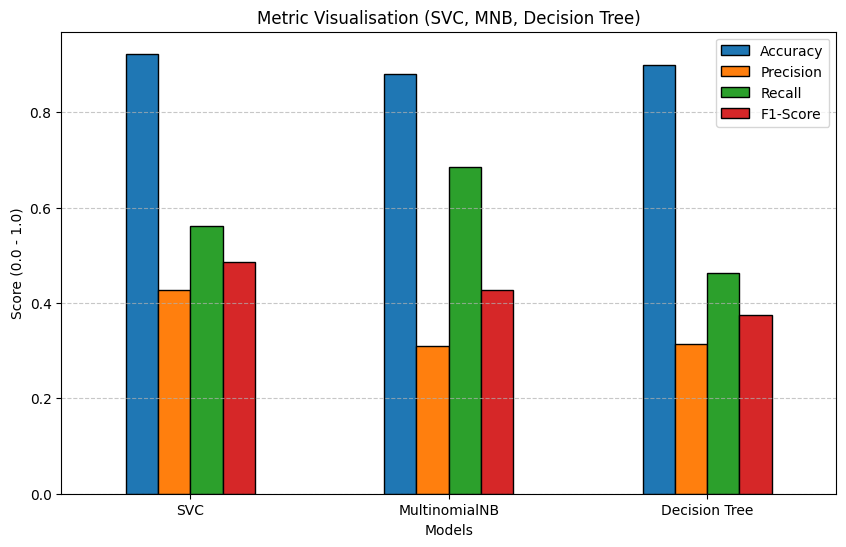

In [ ]:
df_comparison_1.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black'
)

plt.title('Metric Visualisation (SVC, MNB, Decision Tree)')
plt.xlabel('Models')
plt.ylabel('Score (0.0 - 1.0)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.show()


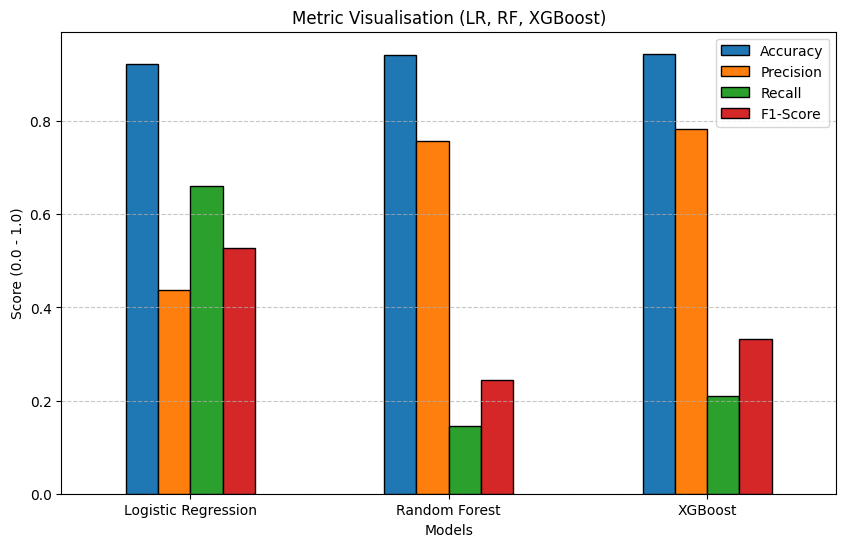

In [ ]:
df_comparison_2.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black'
)

plt.title('Metric Visualisation (LR, RF, XGBoost)')
plt.xlabel('Models')
plt.ylabel('Score (0.0 - 1.0)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.show()

# ⚓ Deep EDA

## ♒Feature Important

In [ ]:
import pandas as pd

importance = xgb.feature_importances_
feature_names = tfidf_vector.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print(feature_importance_df.head(15))

      feature  importance
915     bitch    0.074660
3893      hoe    0.053693
8969     ugly    0.028496
488        as    0.025957
2896  fucking    0.025312
7390     shit    0.023299
2597     fake    0.021348
1873     dick    0.020438
2903      fuk    0.020097
2887     fuck    0.014524
6573    pussy    0.014255
8027   stupid    0.013844
8975       uh    0.013004
7961     stop    0.012897
7920     stfu    0.012148


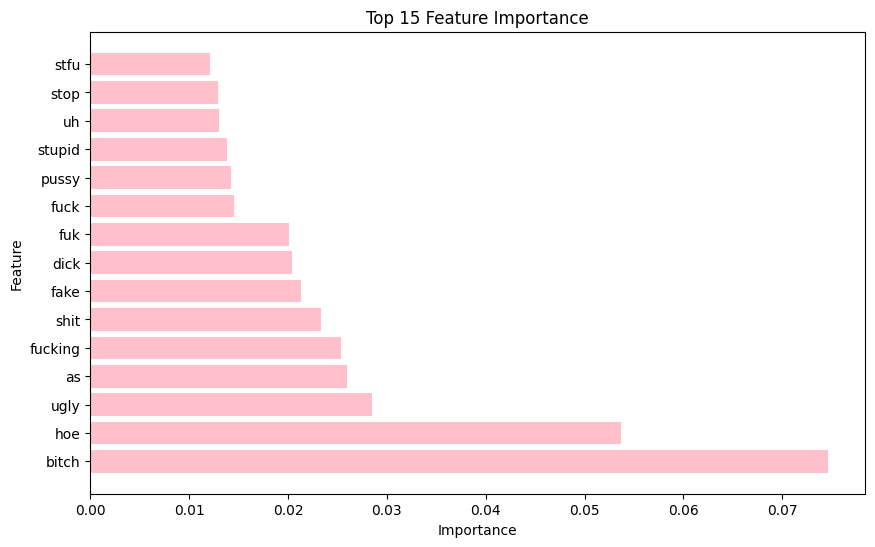

In [ ]:
top_n=15
top_feature = feature_importance_df.head(top_n)
plt.figure(figsize=(10, 6))
plt.barh(top_feature['feature'], top_feature['importance'], color='pink')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Feature Importance')
plt.show()

# ⚓ Error Analysis

## ♒ Categorize Error Types

In [ ]:
y_pred_prob = lr.predict_proba(X_test)[:, 1]
y_pred_label = lr.predict(X_test)

result_df = pd.DataFrame({
    "text":          df.loc[y_test.index, "text"].values,
    "actual":        y_test.values,
    "predicted":     y_pred_label,
    "prob_bullying": y_pred_prob,
})

def label_error_type(row):
    if row["actual"] == row["predicted"]:
        return "correct"
    elif row["actual"] == 0 and row["predicted"] == 1:
        return "false_positive"   # normal → flagged as bullying
    else:
        return "false_negative"   # bullying → missed by model

result_df["error_type"] = result_df.apply(label_error_type, axis=1)

In [ ]:
import numpy as np
result_df["confidence_error"] = np.abs(
    result_df["actual"] - result_df["prob_bullying"]
)

false_positives = (
    result_df[result_df["error_type"] == "false_positive"]
    .sort_values("confidence_error", ascending=False)
    .reset_index(drop=True)
)

false_negatives = (
    result_df[result_df["error_type"] == "false_negative"]
    .sort_values("confidence_error", ascending=False)
    .reset_index(drop=True)
)

total  = len(result_df)
n_fp   = len(false_positives)
n_fn   = len(false_negatives)
n_ok   = total - n_fp - n_fn

print(f"Total test samples : {total}")
print(f"Correct predictions: {n_ok}  ({n_ok/total:.1%})")
print(f"False positives    : {n_fp}  ({n_fp/total:.1%})  ← normal flagged as bullying")
print(f"False negatives    : {n_fn}  ({n_fn/total:.1%})  ← bullying missed by model")

Total test samples : 2630
Correct predictions: 2427  (92.3%)
False positives    : 145  (5.5%)  ← normal flagged as bullying
False negatives    : 58  (2.2%)  ← bullying missed by model


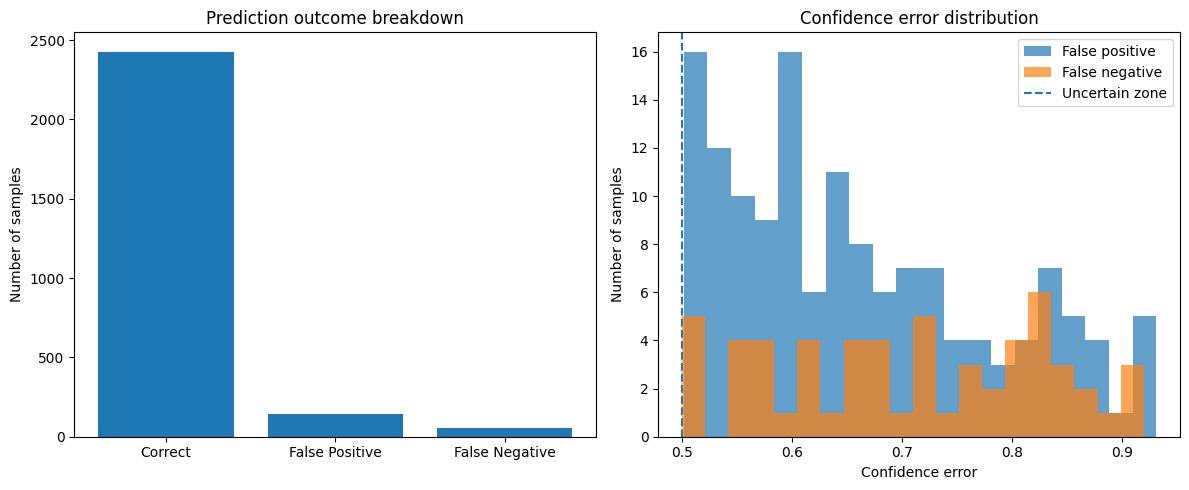

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

counts = [n_ok, n_fp, n_fn]
labels = ["Correct", "False Positive", "False Negative"]

plt.bar(labels, counts)

plt.title("Prediction outcome breakdown")
plt.ylabel("Number of samples")

plt.subplot(1,2,2)

plt.hist(false_positives["confidence_error"],
         bins=20, alpha=0.7,
         label="False positive")

plt.hist(false_negatives["confidence_error"],
         bins=20, alpha=0.7,
         label="False negative")

plt.axvline(0.5, linestyle="--", label="Uncertain zone")

plt.title("Confidence error distribution")
plt.xlabel("Confidence error")
plt.ylabel("Number of samples")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
TOP_N = 10

print(f"Top {TOP_N} False Positives")
print(false_positives[
    ["text", "prob_bullying", "confidence_error"]
].head(TOP_N))

print(f"\nTop {TOP_N} False Negatives")
print(false_negatives[
    ["text", "prob_bullying", "confidence_error"]
].head(TOP_N))

Top 10 False Positives
                                                text  prob_bullying  \
0  Q girl name Tarren half pic WTF going fake giv...       0.931055   
1                           Q fake yurself dont fake       0.930119   
2  Q Whoever said ugly common jealous fuckin whor...       0.921656   
3  Q pathetic fool said toney well never go ur pr...       0.921184   
4                                 Q as mouth 69 im p       0.917216   
5                                      Q gay hahahha       0.891534   
6     Q Mauriciooo stop perverted baby annoying as B       0.882827   
7          Q nigga dese hoe posed pikturesz yar lmao       0.872814   
8                           Q youre dirty tuesdayz p       0.869825   
9                                         Q gay wish       0.868709   

   confidence_error  
0          0.931055  
1          0.930119  
2          0.921656  
3          0.921184  
4          0.917216  
5          0.891534  
6          0.882827  
7          0.872814

## ♒ Text pattern analysis

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

def top_words(texts, top_n=20):
    """Return top_n words by mean TF-IDF score across a text corpus."""
    vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
    tfidf_matrix = vec.fit_transform(texts)
    mean_scores = tfidf_matrix.mean(axis=0).A1
    vocab = vec.get_feature_names_out()
    word_scores = sorted(zip(vocab, mean_scores), key=lambda x: x[1], reverse=True)
    return pd.DataFrame(word_scores[:top_n], columns=["word", "tfidf_score"])

fp_texts = false_positives["text"].tolist()
fn_texts = false_negatives["text"].tolist()

fp_words = top_words(fp_texts)
fn_words = top_words(fn_texts)

print("── Top words in False Positives (normal text the model over-flagged) ──")
display(fp_words)
print("── Top words in False Negatives (bullying the model missed) ──")
display(fn_words)

── Top words in False Positives (normal text the model over-flagged) ──


,word,tfidf_score
0,im,0.052412
1,dont,0.044460
2,like,0.044086
3,lol,0.036758
4,ur,0.036296
5,love,0.034411
6,name,0.027386
7,shit,0.027156
8,fake,0.026864
9,get,0.025666


── Top words in False Negatives (bullying the model missed) ──


,word,tfidf_score
0,im,0.085724
1,know,0.068844
2,lol,0.064765
3,want,0.062851
4,like,0.057569
5,question,0.052654
6,think,0.047735
7,dont,0.046746
8,yew,0.042975
9,love,0.040597


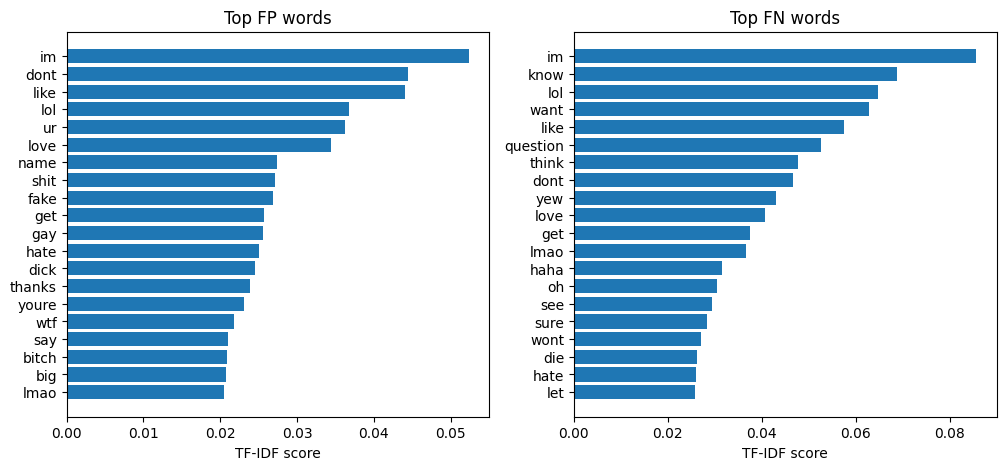

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# False Positive
axes[0].barh(
    fp_words["word"][::-1],
    fp_words["tfidf_score"][::-1]
)
axes[0].set_title("Top FP words")
axes[0].set_xlabel("TF-IDF score")

# False Negative
axes[1].barh(
    fn_words["word"][::-1],
    fn_words["tfidf_score"][::-1]
)
axes[1].set_title("Top FN words")
axes[1].set_xlabel("TF-IDF score")

plt.show()

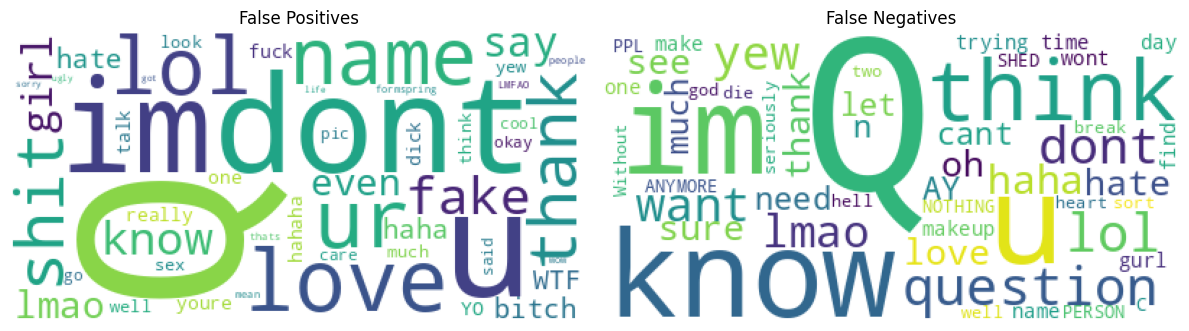

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# False Positive
wc_fp = WordCloud(
    background_color="white",
    max_words=50
).generate(" ".join(fp_texts))

axes[0].imshow(wc_fp)
axes[0].axis("off")
axes[0].set_title("False Positives")

# False Negative
wc_fn = WordCloud(
    background_color="white",
    max_words=50
).generate(" ".join(fn_texts))

axes[1].imshow(wc_fn)
axes[1].axis("off")
axes[1].set_title("False Negatives")

plt.tight_layout()
plt.show()

In [ ]:
fp_vocab = set(fp_words["word"])
fn_vocab = set(fn_words["word"])

fp_only = fp_vocab - fn_vocab   # triggers false flags but not misses
fn_only = fn_vocab - fp_vocab   # present in missed bullying but not over-flags

print("Words exclusive to False Positives (model confuses these as bullying):")
print(fp_only)

print("\nWords exclusive to False Negatives (model misses bullying with these):")
print(fn_only)

Words exclusive to False Positives (model confuses these as bullying):
{'dick', 'thanks', 'youre', 'bitch', 'ur', 'fake', 'big', 'shit', 'gay', 'say', 'name', 'wtf'}

Words exclusive to False Negatives (model misses bullying with these):
{'see', 'sure', 'think', 'know', 'let', 'question', 'wont', 'oh', 'want', 'yew', 'haha', 'die'}


## ♒Error Length & Complexity Analysis

In [ ]:
def compute_text_features(text):
    tokens = text.split()
    n_chars      = len(text)
    n_words      = len(tokens)
    n_unique     = len(set(tokens))
    avg_word_len = np.mean([len(w) for w in tokens]) if tokens else 0
    lexical_div  = n_unique / n_words if n_words > 0 else 0
    return pd.Series({
        "char_count":    n_chars,
        "word_count":    n_words,
        "unique_words":  n_unique,
        "avg_word_len":  round(avg_word_len, 2),
        "lexical_div":   round(lexical_div, 3),
    })

feats = result_df["text"].apply(compute_text_features)
result_df = pd.concat([result_df, feats], axis=1)

summary = (
    result_df
    .groupby("error_type")[[
        "char_count", "word_count", "avg_word_len", "lexical_div"
    ]]
    .agg(["mean", "median"])
    .round(2)
)
print("Text complexity stats by outcome:")
display(summary)

Text complexity stats by outcome:


char_count        word_count        avg_word_len         \
                     mean median       mean median         mean median   
error_type                                                               
correct             77.32   57.0      13.79   10.0         4.56   4.50   
false_negative      66.93   56.0      12.48   10.5         4.37   4.33   
false_positive      64.61   49.0      12.60   11.0         4.02   4.00   

               lexical_div         
                      mean median  
error_type                         
correct               0.94    1.0  
false_negative        0.95    1.0  
false_positive        0.95    1.0

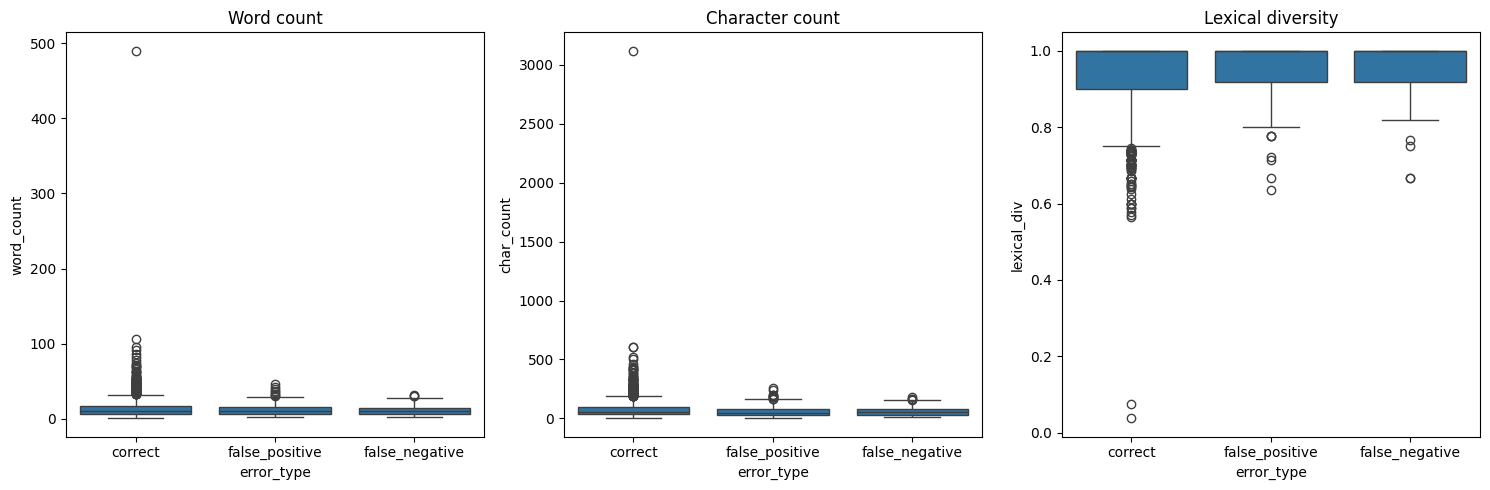

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Word count
sns.boxplot(
    data=result_df,
    x="error_type",
    y="word_count",
    ax=axes[0]
)
axes[0].set_title("Word count")

# Character count
sns.boxplot(
    data=result_df,
    x="error_type",
    y="char_count",
    ax=axes[1]
)
axes[1].set_title("Character count")

# Lexical diversity
sns.boxplot(
    data=result_df,
    x="error_type",
    y="lexical_div",
    ax=axes[2]
)
axes[2].set_title("Lexical diversity")

plt.tight_layout()
plt.show()

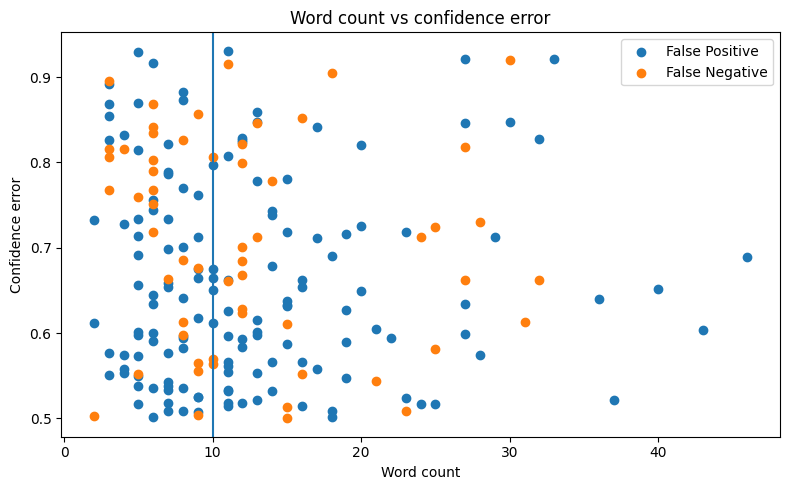

Error rate (≤10 words): 7.6%
Error rate (>10 words): 7.9%


In [ ]:
import matplotlib.pyplot as plt

errors_only = result_df[result_df["error_type"] != "correct"]

fig, ax = plt.subplots(figsize=(8, 5))

# False Positive
fp = errors_only[errors_only["error_type"] == "false_positive"]
ax.scatter(
    fp["word_count"],
    fp["confidence_error"],
    label="False Positive"
)

# False Negative
fn = errors_only[errors_only["error_type"] == "false_negative"]
ax.scatter(
    fn["word_count"],
    fn["confidence_error"],
    label="False Negative"
)

ax.axvline(10)
ax.set_xlabel("Word count")
ax.set_ylabel("Confidence error")
ax.set_title("Word count vs confidence error")
ax.legend()

plt.tight_layout()
plt.show()

short = result_df[result_df["word_count"] <= 10]
long = result_df[result_df["word_count"] > 10]

short_error = (short["error_type"] != "correct").mean()
long_error = (long["error_type"] != "correct").mean()

print(f"Error rate (≤10 words): {short_error:.1%}")
print(f"Error rate (>10 words): {long_error:.1%}")

In [ ]:
# Short texts that model got wrong
short_errors = result_df[
    (result_df["word_count"] <= 10) &
    (result_df["error_type"] != "correct")
]

short_errors = short_errors.sort_values(
    "confidence_error",
    ascending=False
)

print(f"Wrong short texts: {len(short_errors)}")

display(
    short_errors[
        ["text", "error_type", "word_count",
         "prob_bullying", "confidence_error"]
    ].head(10)
)

Wrong short texts: 100


,text,error_type,word_count,prob_bullying,confidence_error
1184,Q fake yurself dont fake,false_positive,5.0,0.930119,0.930119
1482,Q as mouth 69 im p,false_positive,6.0,0.917216,0.917216
495,Q oh god,false_negative,3.0,0.104303,0.895697
348,Q gay hahahha,false_positive,3.0,0.891534,0.891534
681,Q Mauriciooo stop perverted baby annoying as B,false_positive,8.0,0.882827,0.882827
1480,Q nigga dese hoe posed pikturesz yar lmao,false_positive,8.0,0.872814,0.872814
1563,Q youre dirty tuesdayz p,false_positive,5.0,0.869825,0.869825
355,Q see see nothing foolish child,false_negative,6.0,0.131208,0.868792
1856,Q gay wish,false_positive,3.0,0.868709,0.868709
479,Q iightt break yur heart break dickk ahahaha lol,false_negative,9.0,0.142572,0.857428


In [ ]:
# Short texts that model got wrong
long_errors = result_df[
    (result_df["word_count"] > 10) &
    (result_df["error_type"] != "correct")
]

long_errors = long_errors.sort_values(
    "confidence_error",
    ascending=False
)

print(f"Wrong long texts: {len(long_errors)}")

display(
    long_errors[
        ["text", "error_type", "word_count",
         "prob_bullying", "confidence_error"]
    ].head(10)
)

Wrong long texts: 103


,text,error_type,word_count,prob_bullying,confidence_error
2243,Q girl name Tarren half pic WTF going fake giv...,false_positive,11.0,0.931055,0.931055
946,Q Whoever said ugly common jealous fuckin whor...,false_positive,27.0,0.921656,0.921656
1508,Q pathetic fool said toney well never go ur pr...,false_positive,33.0,0.921184,0.921184
1374,Q MEANS NOTHING ANYMORE PERSON SHED TALKED C U...,false_negative,30.0,0.080367,0.919633
2018,Q bet NEMOSTARSHIT COW FAGGET lol well zoblivi...,false_negative,11.0,0.084255,0.915745
2584,Q dang im rollin thaat kind cash question what...,false_negative,18.0,0.094542,0.905458
1672,Q got called bitch LMAO something hate called ...,false_positive,13.0,0.858961,0.858961
1798,Q question seem getting perverted seriously se...,false_negative,16.0,0.148320,0.851680
553,Q damn fuck hater say jordan abzilla love youh...,false_positive,30.0,0.847751,0.847751
1594,Q Yeauh Im Really liar Youre Cool r dont lie s...,false_positive,13.0,0.847301,0.847301


## ♒Compare Error Rates Across Models

In [ ]:
models = {
    "SVC":                 svc,
    "MultinomialNB":       mnb,
    "Decision Tree":       dtc,
    "Logistic Regression": lr,
    "Random Forest":       rfc,
    "XGBoost":             xgb,
}

pred_df = pd.DataFrame(
    {name: model.predict(X_test) for name, model in models.items()},
    index=y_test.index
)
pred_df.insert(0, "actual", y_test.values)

print("Prediction matrix shape:", pred_df.shape)
display(pred_df.head(10))
print(pred_df["actual"].value_counts())

Prediction matrix shape: (2630, 7)


,actual,SVC,MultinomialNB,Decision Tree,Logistic Regression,Random Forest,XGBoost
11940,0,0,0,0,0,0,0
6651,0,0,0,0,0,0,0
12577,0,0,0,0,0,0,0
10839,0,0,0,0,0,0,0
13065,0,0,0,0,0,0,0
4352,0,0,0,0,0,0,0
2357,0,0,0,0,0,0,0
12430,0,0,0,0,0,0,0
1634,0,0,0,0,0,0,0
5843,0,0,0,0,0,0,0


actual
0    2459
1     171
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rows = []
for name in models:
    y_pred = pred_df[name]
    fp = ((pred_df["actual"] == 0) & (y_pred == 1)).sum()
    fn = ((pred_df["actual"] == 1) & (y_pred == 0)).sum()
    n  = len(y_test)
    rows.append({
        "Model":       name,
        "Accuracy":    accuracy_score(y_test, y_pred),
        "F1":          f1_score(y_test, y_pred),
        "Precision":   precision_score(y_test, y_pred),
        "Recall":      recall_score(y_test, y_pred),
        "FP count":    fp,
        "FN count":    fn,
        "FP rate":     fp / n,
        "FN rate":     fn / n,
        "Total errors": fp + fn,
    })

metrics_df = pd.DataFrame(rows).set_index("Model")

print("Per-model error breakdown:")
display(
    metrics_df
    .sort_values("F1", ascending=False)
    .style
    .background_gradient(subset=["F1", "Accuracy"], cmap="Greens")
    .background_gradient(subset=["FP rate", "FN rate"], cmap="Reds")
    .format({
        "Accuracy": "{:.3f}", "F1": "{:.3f}",
        "Precision": "{:.3f}", "Recall": "{:.3f}",
        "FP rate": "{:.1%}", "FN rate": "{:.1%}",
    })
)

Per-model error breakdown:


,Accuracy,F1,Precision,Recall,FP count,FN count,FP rate,FN rate,Total errors
Model,,,,,,,,,
Logistic Regression,0.923,0.527,0.438,0.661,145,58,5.5%,2.2%,203
SVC,0.922,0.485,0.427,0.561,129,75,4.9%,2.9%,204
MultinomialNB,0.881,0.427,0.310,0.684,260,54,9.9%,2.1%,314
Decision Tree,0.900,0.374,0.315,0.462,172,92,6.5%,3.5%,264
XGBoost,0.945,0.332,0.783,0.211,10,135,0.4%,5.1%,145
Random Forest,0.941,0.245,0.758,0.146,8,146,0.3%,5.6%,154


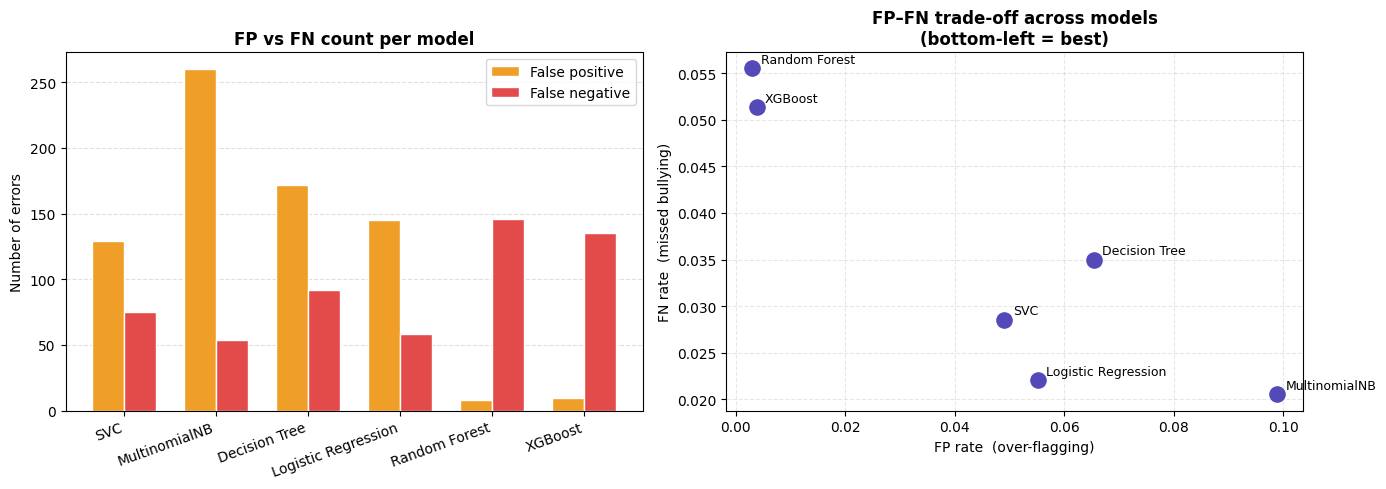

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = metrics_df.index.tolist()
x = np.arange(len(model_names))
w = 0.35

# ── Left: FP vs FN count per model ────────────────────────────────────
axes[0].bar(x - w/2, metrics_df["FP count"], width=w,
            label="False positive", color="#EF9F27", edgecolor="white")
axes[0].bar(x + w/2, metrics_df["FN count"], width=w,
            label="False negative", color="#E24B4A", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=20, ha="right")
axes[0].set_title("FP vs FN count per model", fontweight="bold")
axes[0].set_ylabel("Number of errors")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].set_axisbelow(True)

# ── Right: scatter — FP rate vs FN rate (trade-off view) ──────────────
axes[1].scatter(
    metrics_df["FP rate"], metrics_df["FN rate"],
    s=120, color="#534AB7", zorder=3
)
for name, row in metrics_df.iterrows():
    axes[1].annotate(
        name,
        (row["FP rate"], row["FN rate"]),
        textcoords="offset points", xytext=(6, 4), fontsize=9
    )
axes[1].set_xlabel("FP rate  (over-flagging)")
axes[1].set_ylabel("FN rate  (missed bullying)")
axes[1].set_title("FP–FN trade-off across models\n(bottom-left = best)",
                  fontweight="bold")
axes[1].grid(linestyle="--", alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

In [ ]:
model_cols = list(models.keys())
if "length_group" not in result_df.columns:
    result_df["length_group"] = pd.cut(
        result_df["word_count"],
        bins=[0, 10, 50, float("inf")],
        labels=["short (≤10)", "medium (11–50)", "long (>50)"]
    )
# ── Count how many models were wrong on each sample ───────────────────
pred_df["n_wrong"] = pred_df.apply(
    lambda row: sum(row[m] != row["actual"] for m in model_cols), axis=1
)

# ── Agreement tiers ────────────────────────────────────────────────────
pred_df["difficulty"] = pd.cut(
    pred_df["n_wrong"],
    bins=[-1, 0, 2, 4, 6],
    labels=["all correct", "easy error (1–2)", "hard error (3–4)", "impossible (5–6)"]
)

diff_counts = pred_df["difficulty"].value_counts().sort_index()
print("Sample difficulty distribution:")
display(diff_counts.to_frame("count"))

# ── True hard cases: all 6 models wrong ───────────────────────────────
hard_samples = (
    pred_df[pred_df["n_wrong"] == 6]
    .merge(
        result_df[["text", "word_count", "length_group"]],
        left_index=True, right_index=True
    )
    .sort_values("actual")
)

print(f"\nSamples ALL 6 models got wrong: {len(hard_samples)}")
display(
    hard_samples[["text", "actual"] + model_cols + ["word_count", "length_group"]]
    .head(20)
    .style
    .applymap(
        lambda v: "background: #fde8e8" if v == 1 else "background: #e8f5e8",
        subset=model_cols
    )
)

pred_df.shape

Sample difficulty distribution:


,count
difficulty,
all correct,2082
easy error (1–2),338
hard error (3–4),141
impossible (5–6),69



Samples ALL 6 models got wrong: 6


/tmp/ipykernel_870/738170591.py:39: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(


,text,actual,SVC,MultinomialNB,Decision Tree,Logistic Regression,Random Forest,XGBoost,word_count,length_group
624,Q Looking HOT today hoping youd notice,1,0,0,0,0,0,0,7.000000,short (≤10)
385,Q heeeeeeeeeeeyyyyyya grlywhacha doincall lataz there sum asian da club tonitewanna hook hey dude much whats number lol azns club im cause im azn right,1,0,0,0,0,0,0,25.000000,medium (11–50)
608,Q single looking would place youd try meet new people Online Bar Motorcycle Rallyies,1,0,0,0,0,0,0,14.000000,medium (11–50)
410,Q didnt go salsa World music Hugh mix Also big fight aw wat happen,1,0,0,0,0,0,0,14.000000,medium (11–50)
1669,Q act youre sad Thats go quiet definitely probably give pretty short answer usually easy tell know well enough upset something Either come ranting 3,1,0,0,0,0,0,0,25.000000,medium (11–50)
2435,Q wake open eye first honestly think wake opening eye go thru REM cycle sleep,1,0,0,0,0,0,0,15.000000,medium (11–50)


(2630, 9)

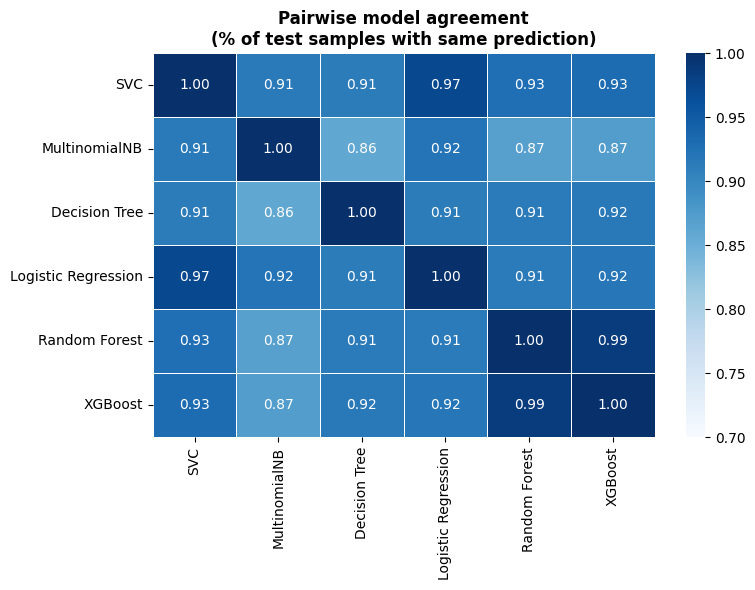


Samples where only ONE model was wrong (model-specific weakness):
SVC 8 unique errors
MultinomialNB 134 unique errors
Decision Tree 88 unique errors
Logistic Regression 9 unique errors
Random Forest 11 unique errors
XGBoost 4 unique errors


In [ ]:
# ── Pairwise agreement: % of test samples where both models agree ──────
agreement = pd.DataFrame(
    np.zeros((len(model_cols), len(model_cols))),
    index=model_cols, columns=model_cols
)
for m1 in model_cols:
    for m2 in model_cols:
        agreement.loc[m1, m2] = (pred_df[m1] == pred_df[m2]).mean()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    agreement, annot=True, fmt=".2f",
    cmap="Blues", vmin=0.7, vmax=1.0,
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_title("Pairwise model agreement\n(% of test samples with same prediction)",
            fontweight="bold")
plt.tight_layout()
plt.show()

print("\nSamples where only ONE model was wrong (model-specific weakness):")
for m in model_cols:
    others = [c for c in model_cols if c != m]

    # combine all "other models correct" conditions into one boolean Series
    others_correct = np.logical_and.reduce(
        [pred_df[o] == pred_df["actual"] for o in others]
    )

    solo_err = pred_df[
        (pred_df[m] != pred_df["actual"]) & others_correct
    ]
    print(m, len(solo_err), "unique errors")

## ♒Confidence Distribution Plot

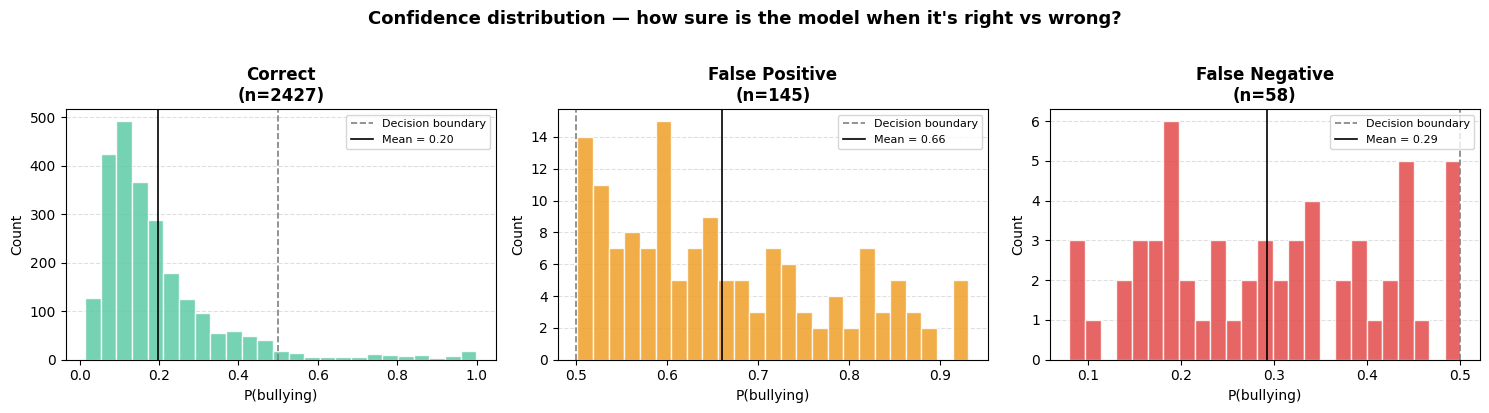

In [ ]:
# ── Use LR probabilities already in result_df ─────────────────────────
correct_probs = result_df.loc[
    result_df["error_type"] == "correct", "prob_bullying"
]
fp_probs = result_df.loc[
    result_df["error_type"] == "false_positive", "prob_bullying"
]
fn_probs = result_df.loc[
    result_df["error_type"] == "false_negative", "prob_bullying"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, probs, label, color in zip(
    axes,
    [correct_probs,        fp_probs,                      fn_probs],
    ["Correct",           "False Positive",              "False Negative"],
    ["#5DCAA5",           "#EF9F27",                     "#E24B4A"],
):
    ax.hist(probs, bins=25, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0.5, color="gray",  linestyle="--", linewidth=1.2, label="Decision boundary")
    ax.axvline(probs.mean(), color="black", linestyle="-",  linewidth=1.2,
               label=f"Mean = {probs.mean():.2f}")
    ax.set_title(f"{label}\n(n={len(probs)})", fontweight="bold")
    ax.set_xlabel("P(bullying)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

plt.suptitle(
    "Confidence distribution — how sure is the model when it's right vs wrong?",
    fontweight="bold", fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

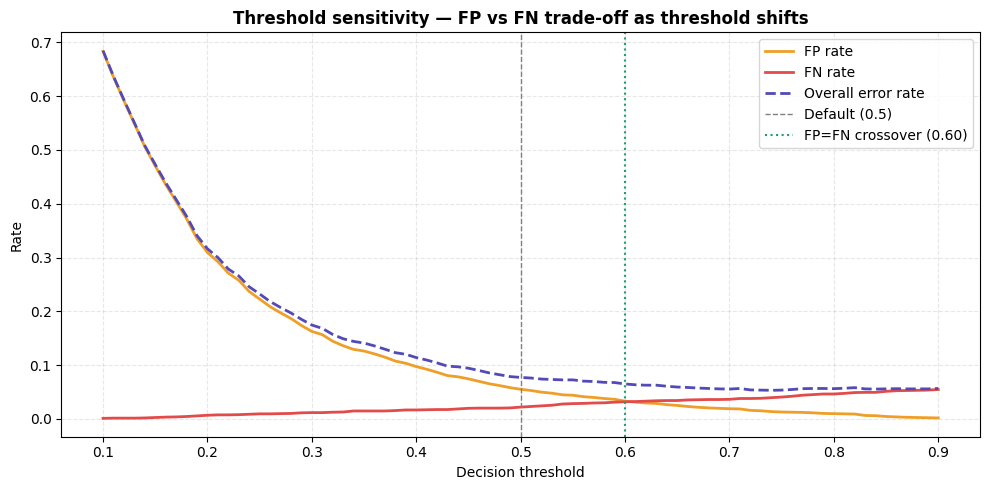

Crossover threshold (FP rate ≈ FN rate): 0.60
Overall error rate at crossover          : 6.5%
Overall error rate at default (0.5)      : 9.4%


In [ ]:
thresholds = np.linspace(0.1, 0.9, 81)
fp_rates, fn_rates, err_rates = [], [], []

for t in thresholds:
    y_pred_t = (result_df["prob_bullying"] >= t).astype(int)
    n        = len(result_df)
    fp_rates.append(((result_df["actual"] == 0) & (y_pred_t == 1)).sum() / n)
    fn_rates.append(((result_df["actual"] == 1) & (y_pred_t == 0)).sum() / n)
    err_rates.append((result_df["actual"] != y_pred_t).sum() / n)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, fp_rates,  color="#EF9F27", linewidth=2, label="FP rate")
ax.plot(thresholds, fn_rates,  color="#E24B4A", linewidth=2, label="FN rate")
ax.plot(thresholds, err_rates, color="#534AB7", linewidth=2, label="Overall error rate",
        linestyle="--")

# ── Mark current default threshold ────────────────────────────────────
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Default (0.5)")

# ── Mark crossover point (where FP rate == FN rate) ───────────────────
crossover_idx = np.argmin(np.abs(np.array(fp_rates) - np.array(fn_rates)))
crossover_t   = thresholds[crossover_idx]
ax.axvline(crossover_t, color="#1D9E75", linestyle=":", linewidth=1.5,
           label=f"FP=FN crossover ({crossover_t:.2f})")

ax.set_xlabel("Decision threshold")
ax.set_ylabel("Rate")
ax.set_title(
    "Threshold sensitivity — FP vs FN trade-off as threshold shifts",
    fontweight="bold"
)
ax.legend()
ax.grid(linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"Crossover threshold (FP rate ≈ FN rate): {crossover_t:.2f}")
print(f"Overall error rate at crossover          : {err_rates[crossover_idx]:.1%}")
print(f"Overall error rate at default (0.5)      : {err_rates[list(thresholds).index(next(t for t in thresholds if round(t,1)==0.5))]:.1%}")

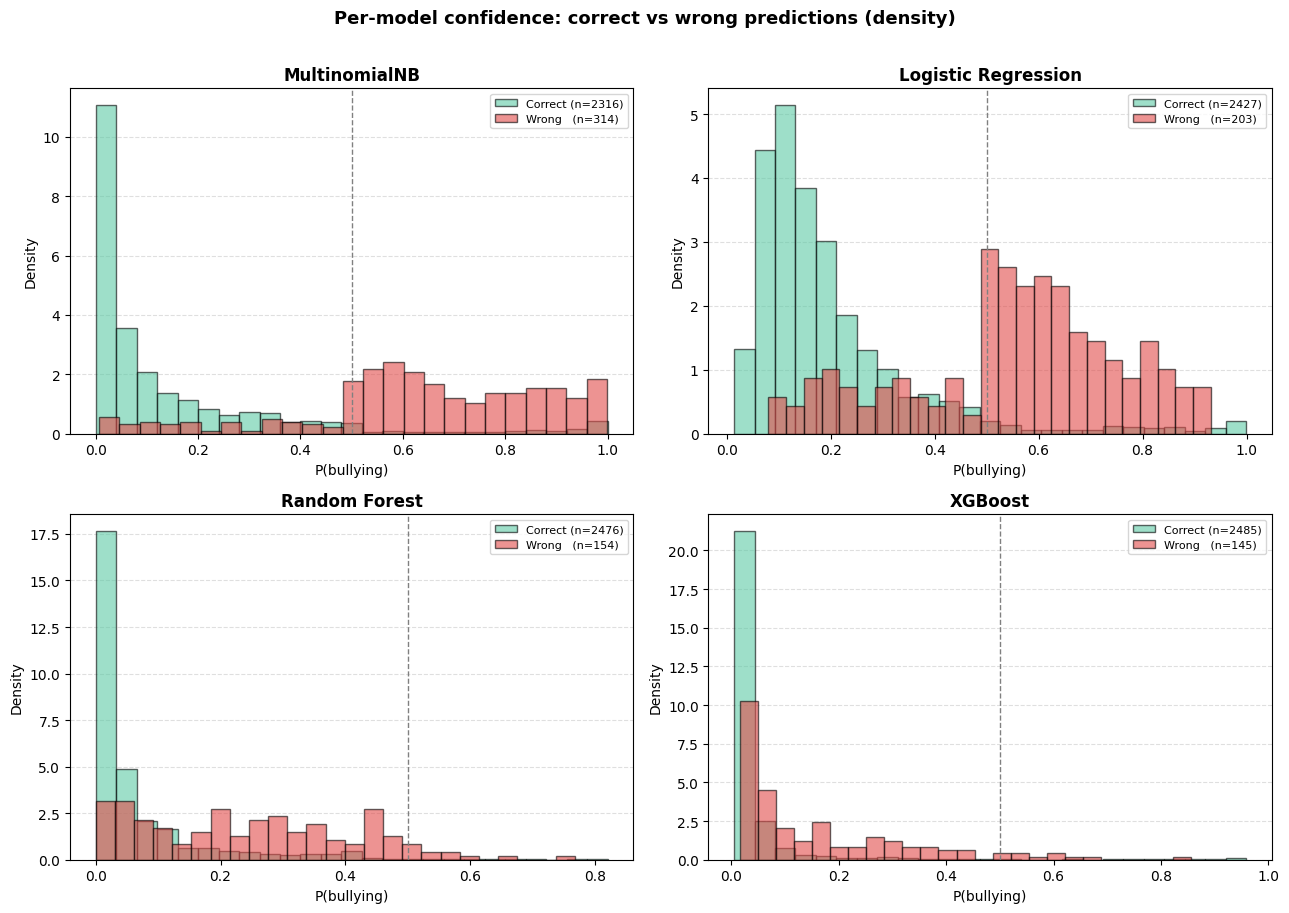

In [ ]:
proba_models = {
    "MultinomialNB":       mnb,
    "Logistic Regression": lr,
    "Random Forest":       rfc,
    "XGBoost":             xgb,
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (name, model) in zip(axes, proba_models.items()):
    probs    = model.predict_proba(X_test)[:, 1]
    preds    = model.predict(X_test)
    correct  = probs[preds == y_test.values]
    wrong    = probs[preds != y_test.values]

    ax.hist(correct, bins=25, alpha=0.6, color="#5DCAA5",
            edgecolor="black", label=f"Correct (n={len(correct)})",
            density=True)
    ax.hist(wrong,   bins=25, alpha=0.6, color="#E24B4A",
            edgecolor="black", label=f"Wrong   (n={len(wrong)})",
            density=True)
    ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("P(bullying)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

plt.suptitle(
    "Per-model confidence: correct vs wrong predictions (density)",
    fontweight="bold", fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# ⚓Threshold tuning

In [ ]:
y_scores = lr.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best Threshold: {best_threshold_f1:.4f}")
print(f"Best F1-Score        : {best_f1:.4f}")

Best Threshold: 0.4962
Best F1-Score        : 0.5309


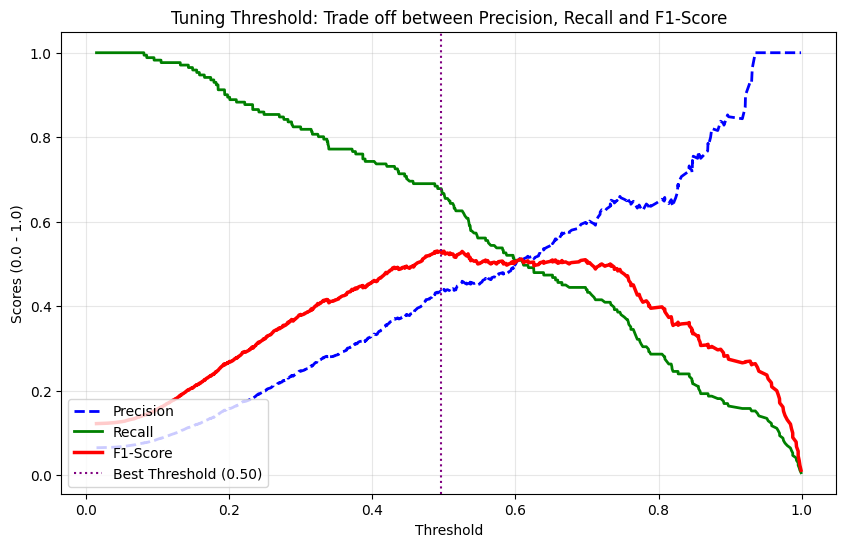

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall', linewidth=2)
plt.plot(thresholds, f1_scores[:-1], 'r-', label='F1-Score', linewidth=2.5)

plt.axvline(best_threshold_f1, color='purple', linestyle=':', label=f'Best Threshold ({best_threshold_f1:.2f})')

plt.title('Tuning Threshold: Trade off between Precision, Recall and F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Scores (0.0 - 1.0)')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
final_threshold = best_threshold_f1

y_pred_new = (y_scores >= final_threshold).astype(int)

print(f"\n Result report with new threshold ({final_threshold:.4f})")
print("=" * 60)
print("Old confusion matrix")
print(confusion_matrix(y_test, y_pred))
print("New Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_new))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_new))


 Result report with new threshold (0.4962)
Old confusion matrix
[[2449   10]
 [ 135   36]]
New Confusion Matrix:
[[2309  150]
 [  55  116]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      2459
           1       0.44      0.68      0.53       171

    accuracy                           0.92      2630
   macro avg       0.71      0.81      0.74      2630
weighted avg       0.94      0.92      0.93      2630



# ⚓ Model Improvement

## ♒re-weight hard samples

In [ ]:
y_train_pred = lr.predict(X_train)

pred_train_df = pd.DataFrame({
    'y_true': y_train,
    'y_pred': y_train_pred
}, index=y_train.index)

hard_indices = pred_train_df[pred_train_df['y_true'] != pred_train_df['y_pred']].index

sample_weights = np.ones(len(y_train))
train_hard_positions = y_train.index.get_indexer(hard_indices)
train_hard_positions = train_hard_positions[train_hard_positions != -1]

sample_weights[train_hard_positions] = 3.0

lr_v2 = LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000)
lr_v2.fit(X_train, y_train, sample_weight=sample_weights)

print("=== COMPARE RESULT IN TEST SET ===")
for name, model in {"LR original": lr, "LR v2 (weighted)": lr_v2}.items():
    y_pred = model.predict(X_test)
    print(f"{name:22}  F1={f1_score(y_test, y_pred):.3f}  "
          f"Recall={recall_score(y_test, y_pred):.3f}  "
          f"Precision={precision_score(y_test, y_pred):.3f}")

=== COMPARE RESULT IN TEST SET ===
LR original             F1=0.527  Recall=0.661  Precision=0.438
LR v2 (weighted)        F1=0.501  Recall=0.561  Precision=0.453


## ♒Add handcrafted features

In [ ]:
from scipy.sparse import hstack, csr_matrix

def extract_extra_features(texts):
    features = []
    for t in texts:
        raw     = str(t)
        tokens  = raw.split()
        features.append([
            len(tokens),                                         # word count
            len(raw),                                            # char count
            sum(c == "!" for c in raw),
            sum(c == "?" for c in raw),
            sum(w.isupper() and len(w) > 1 for w in tokens),  # ALL CAPS words
            raw.count("..."),                                   # ellipsis
            len(set(tokens)) / (len(tokens) + 1e-8),           # lexical diversity
        ])
    return csr_matrix(np.array(features, dtype=np.float32))

raw_train = df.loc[y_train.index, "text"].tolist()
raw_test  = df.loc[y_test.index,  "text"].tolist()

extra_train = extract_extra_features(raw_train)
extra_test  = extract_extra_features(raw_test)

X_train_v2 = hstack([X_train, extra_train])
X_test_v2  = hstack([X_test,  extra_test])

print(f"Original feature shape : {X_train.shape}")
print(f"Enhanced feature shape : {X_train_v2.shape}")

# ── Re-train LR on enhanced features ───
lr_v3 = LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000)
lr_v3.fit(X_train_v2, y_train)

y_pred_v3 = lr_v3.predict(X_test_v2)
print(f"\nLR v3 (TF-IDF + hand features)")
print(f"F1={f1_score(y_test,y_pred_v3):.3f}  "
      f"Recall={recall_score(y_test,y_pred_v3):.3f}  "
      f"Precision={precision_score(y_test,y_pred_v3):.3f}")

Original feature shape : (10517, 10000)
Enhanced feature shape : (10517, 10007)

LR v3 (TF-IDF + hand features)
F1=0.510  Recall=0.661  Precision=0.415


## ♒Soft voting

In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ("svc", SVC(kernel="linear", gamma=1.0,
                   class_weight="balanced", probability=True)),
        ("lr",  LogisticRegression(random_state=42,
                   class_weight="balanced", max_iter=1000)),
    ],
    voting="soft"   # average probabilities, not hard votes
)
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)

print("Ensemble (SVC + LR soft voting)")
print(f"F1={f1_score(y_test,y_pred_ens):.3f}  "
      f"Recall={recall_score(y_test,y_pred_ens):.3f}  "
      f"Precision={precision_score(y_test,y_pred_ens):.3f}")

Ensemble (SVC + LR soft voting)
F1=0.477  Recall=0.415  Precision=0.559


In [ ]:
versions = {
    "LR original":           (lr,         X_test),
    "LR v2 (hard re-weight)": (lr_v2,      X_test),
    "LR v3 (+ hand features)":(lr_v3,      X_test_v2),
    "Ensemble SVC+LR":        (ensemble,    X_test),
}

rows = []
for name, (model, X) in versions.items():
    y_p = model.predict(X)
    rows.append({
        "Version":   name,
        "F1":        f1_score(y_test, y_p),
        "Recall":    recall_score(y_test, y_p),
        "Precision": precision_score(y_test, y_p),
        "FN count":  ((y_test == 1) & (y_p == 0)).sum(),
        "FP count":  ((y_test == 0) & (y_p == 1)).sum(),
    })

cmp = pd.DataFrame(rows).set_index("Version").round(3)
display(
    cmp.sort_values("F1", ascending=False)
    .style
    .background_gradient(subset=["F1", "Recall"], cmap="Greens")
    .background_gradient(subset=["FN count", "FP count"], cmap="Reds_r")
)

,F1,Recall,Precision,FN count,FP count
Version,,,,,
LR original,0.527000,0.661000,0.438000,58,145
LR v3 (+ hand features),0.510000,0.661000,0.415000,58,159
LR v2 (hard re-weight),0.501000,0.561000,0.453000,75,116
Ensemble SVC+LR,0.477000,0.415000,0.559000,100,56


# ⚓Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced', {0: 1, 1: 1.5}, {0: 1, 1: 2}]
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameter:", grid_search.best_params_)
print("Higest F1-score on Validation Fold:", grid_search.best_score_)

best_lr = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameter: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Higest F1-score on Validation Fold: 0.5221150275393664


In [ ]:
y_prob_test = best_lr.predict_proba(X_test)[:, 1]

y_pred_custom = (y_prob_test >= best_threshold_f1).astype(int)

print(f"--- NEW RESULT WITH THE BEST THRESHOLD = {best_threshold_f1} ---")
print(f"F1: {f1_score(y_test, y_pred_custom):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_custom):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_custom):.3f}")

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()
print(f"(FN): {fn}")
print(f"(FP): {fp}")

--- NEW RESULT WITH THE BEST THRESHOLD = 0.49617072235446824 ---
F1: 0.489
Recall: 0.538
Precision: 0.449
(FN): 79
(FP): 113


#✈ Final Model

In [ ]:
y_prob_tuned = best_lr.predict_proba(X_test)[:, 1]

precision_t, recall_t, thresholds_t = precision_recall_curve(y_test, y_prob_tuned)
f1_t = 2 * (precision_t[:-1] * recall_t[:-1]) / (
       precision_t[:-1] + recall_t[:-1] + 1e-8)

best_threshold_tuned = thresholds_t[np.argmax(f1_t)]
print(f"Old threshold (from original LR) : {best_threshold_f1:.4f}")
print(f"New threshold (from tuned LR)    : {best_threshold_tuned:.4f}")

y_pred_tuned = (y_prob_tuned >= best_threshold_tuned).astype(int)

y_pred_original = (lr.predict_proba(X_test)[:, 1] >= best_threshold_f1).astype(int)

results = pd.DataFrame([
    {
        "Version":   "LR original + its threshold",
        "Threshold": round(best_threshold_f1, 4),
        "F1":        f1_score(y_test, y_pred_original),
        "Recall":    recall_score(y_test, y_pred_original),
        "Precision": precision_score(y_test, y_pred_original),
        "FN": ((y_test==1) & (y_pred_original==0)).sum(),
        "FP": ((y_test==0) & (y_pred_original==1)).sum(),
    },
    {
        "Version":   "LR tuned + its own threshold",
        "Threshold": round(best_threshold_tuned, 4),
        "F1":        f1_score(y_test, y_pred_tuned),
        "Recall":    recall_score(y_test, y_pred_tuned),
        "Precision": precision_score(y_test, y_pred_tuned),
        "FN": ((y_test==1) & (y_pred_tuned==0)).sum(),
        "FP": ((y_test==0) & (y_pred_tuned==1)).sum(),
    },
]).set_index("Version").round(3)

display(
    results.style
    .background_gradient(subset=["F1", "Recall"], cmap="Greens")
    .background_gradient(subset=["FN", "FP"], cmap="Reds_r")
)

Old threshold (from original LR) : 0.4962
New threshold (from tuned LR)    : 0.4713


,Threshold,F1,Recall,Precision,FN,FP
Version,,,,,,
LR original + its threshold,0.496000,0.531000,0.678000,0.436000,55,150
LR tuned + its own threshold,0.471000,0.503000,0.573000,0.447000,73,121


# ✈Deployment

In [ ]:
import joblib
import json
import os

save_dir = "/content/drive/MyDrive/Project ML/Project_Cyber_Bullying"

os.makedirs(save_dir, exist_ok=True)

joblib.dump(tfidf_vector, f"{save_dir}/tfidf_vectorizer.pkl")
joblib.dump(lr, f"{save_dir}/lr_model.pkl")

metadata = {
    "threshold": best_threshold_f1,
    "model_type": "LogisticRegression",
    "tfidf_features": 10000,
    "ngram_range": "(1,2)",
    "test_f1": 0.531,
    "test_recall": 0.678,
    "test_precision": 0.436,
    "labels": {"0": "normal", "1": "bullying"},
}

with open(f"{save_dir}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved!")

Saved!
